# **Enviroment** **setup**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd
import numpy as np
import re
import nltk
from nltk.tokenize import word_tokenize
import openai


Dataset Loading and splitting

In [ ]:

train_url = "https://huggingface.co/datasets/amarshiv86/sentiment-analysis-imdb-dataset/resolve/main/data/train.csv"
test_url  = "https://huggingface.co/datasets/amarshiv86/sentiment-analysis-imdb-dataset/resolve/main/data/test.csv"

train_df = pd.read_csv(train_url)
test_df  = pd.read_csv(test_url)

train_df.head()
train_df.info()
train_df['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5000 non-null   object
 1   label   5000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 78.3+ KB


,count
label,
0,2515
1,2485


Cleaning and Preprocessing

In [ ]:

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text'] = test_df['text'].apply(clean_text)
train_df[['text', 'clean_text']].head()

,text,clean_text
0,"Dumb is as dumb does, in this thoroughly unint...",dumb is as dumb does in this thoroughly uninte...
1,I dug out from my garage some old musicals and...,i dug out from my garage some old musicals and...
2,After watching this movie I was honestly disap...,after watching this movie i was honestly disap...
3,This movie was nominated for best picture but ...,this movie was nominated for best picture but ...
4,Just like Al Gore shook us up with his painful...,just like al gore shook us up with his painful...


## Tokenization


The cleaned text was split into individual words using NLTK word_tokenize()

In [ ]:

nltk.download('punkt')
nltk.download('punkt_tab')
train_df['tokens'] = train_df['clean_text'].apply(word_tokenize)
test_df['tokens'] = test_df['clean_text'].apply(word_tokenize)
train_df[['clean_text', 'tokens']].head()

train_df[['clean_text', 'tokens']].head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,clean_text,tokens
0,dumb is as dumb does in this thoroughly uninte...,"[dumb, is, as, dumb, does, in, this, thoroughl..."
1,i dug out from my garage some old musicals and...,"[i, dug, out, from, my, garage, some, old, mus..."
2,after watching this movie i was honestly disap...,"[after, watching, this, movie, i, was, honestl..."
3,this movie was nominated for best picture but ...,"[this, movie, was, nominated, for, best, pictu..."
4,just like al gore shook us up with his painful...,"[just, like, al, gore, shook, us, up, with, hi..."


## Stopword Removal

In [ ]:
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

train_df['tokens'] = train_df['tokens'].apply(
    lambda x: [word for word in x if word not in stop_words]
)

test_df['tokens'] = test_df['tokens'].apply(
    lambda x: [word for word in x if word not in stop_words]
)
train_df['final_text'] = train_df['tokens'].apply(lambda x: " ".join(x))
test_df['final_text'] = test_df['tokens'].apply(lambda x: " ".join(x))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## Feature Extraction using TF-IDF


 we used TF-IDF to convert the  text into numerical feature vectors for machine learning models

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(train_df['final_text'])
X_test = vectorizer.transform(test_df['final_text'])

y_train = train_df['label']
y_test = test_df['label']
print(X_train.shape)
print(vectorizer.get_feature_names_out()[:20])

(5000, 5000)
['abandoned' 'abc' 'abilities' 'ability' 'able' 'absence' 'absolute'
 'absolutely' 'absurd' 'absurdity' 'abu' 'abuse' 'abused' 'abusive'
 'abysmal' 'academy' 'accent' 'accents' 'accept' 'acceptable']


# Traditional Approach



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred_lr = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_lr))


Accuracy: 0.854


In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.828


In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.84


##Traditional Approach models evaluation

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = {
    "Model": ["Logistic", "SVM", "Naive Bayes"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_nb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr, average='weighted'),
        precision_score(y_test, y_pred_svm, average='weighted'),
        precision_score(y_test, y_pred_nb, average='weighted')
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr, average='weighted'),
        recall_score(y_test, y_pred_svm, average='weighted'),
        recall_score(y_test, y_pred_nb, average='weighted')
    ],
    "F1": [
        f1_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_test, y_pred_svm, average='weighted'),
        f1_score(y_test, y_pred_nb, average='weighted')
    ]
}
df_results = pd.DataFrame(results)

df_results = df_results.round(4)
print(df_results)

         Model  Accuracy  Precision  Recall      F1
0     Logistic     0.854     0.8542   0.854  0.8540
1          SVM     0.840     0.8400   0.840  0.8400
2  Naive Bayes     0.828     0.8290   0.828  0.8277


In [ ]:
def evaluate_model(y_true, y_pred, model_name="Model"):
    print(f"=== {model_name} ===")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall:", recall_score(y_true, y_pred, average='weighted'))
    print("F1-score:", f1_score(y_true, y_pred, average='weighted'))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

=== Logistic Regression ===
Accuracy: 0.854
Precision: 0.8542058408233634
Recall: 0.854
F1-score: 0.8540175225232434


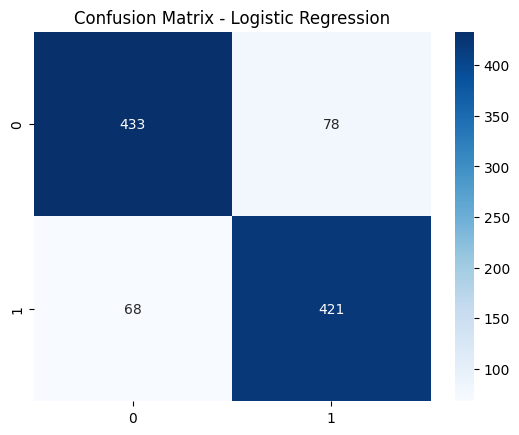

=== SVM ===
Accuracy: 0.84
Precision: 0.839991354155409
Recall: 0.84
F1-score: 0.8399923155737705


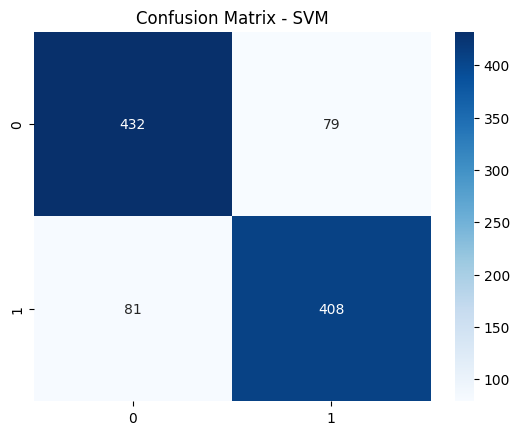

=== Naive Bayes ===
Accuracy: 0.828
Precision: 0.8289602164957172
Recall: 0.828
F1-score: 0.827730952495548


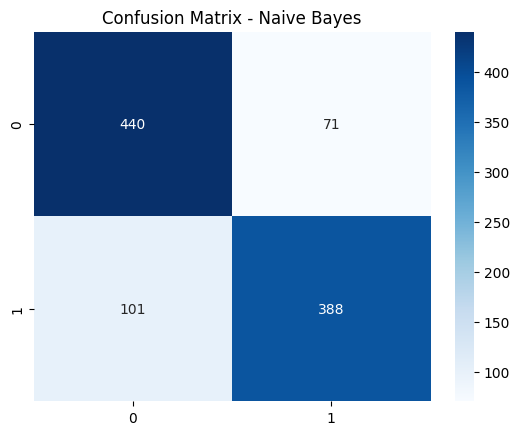

In [ ]:
evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_svm, "SVM")
evaluate_model(y_test, y_pred_nb, "Naive Bayes")

#  Large Language Model (LLM) Approach

In [ ]:
import torch
torch.cuda.empty_cache()

In [ ]:
!pip install -q transformers accelerate bitsandbytes sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.0 MB/s eta 0:00:00


In [ ]:
import re
import torch

from huggingface_hub import login

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)

In [ ]:
access_token = "YOUR_HF_TOKEN"
login(token=access_token)

In [ ]:
def prompt(text):

    return f"""
[INST]
Classify the sentiment.

Example 1:
Review: "I loved the movie!"
Answer: Positive

Example 2:
Review: "The film was terrible."
Answer: Negative

Now classify this review:
{text}

Return ONLY: Positive or Negative
[/INST]
"""



In [ ]:

model_name = "ALLaM-AI/ALLaM-7B-Instruct-preview"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True)


tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    token=access_token)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    low_cpu_mem_usage=True,
    token=access_token)

config.json:   0%|          | 0.00/686 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer.model:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

In [ ]:

def allam_model(prompt_text):
    messages = [ {"role": "user", "content": prompt_text } ]

    inputs = tokenizer.apply_chat_template(  messages,tokenize=False )
    inputs = tokenizer( inputs, return_tensors='pt', return_token_type_ids=False )
    inputs = {k: v.to("cuda") for k, v in inputs.items()}

    response = model.generate(
    **inputs,
    max_new_tokens=20,
    temperature=0,
    do_sample=False,
    pad_token_id=tokenizer.eos_token_id)

    prediction = tokenizer.decode(
        response[0],
        skip_special_tokens=True )

    print(prediction)

    if "positive" in prediction.lower():
        return "Positive"

    elif "negative" in prediction.lower():
          return "Negative"

    else:
        return "Unknown"

In [ ]:
sample = "I really loved this movie."
query = prompt(sample)
result = allam_model(query)
print(result)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[ IN ST ] [ IN ST ] Cl ass ify the se nt im ent . Ex amp le 1 : Re view : " I lo ved the mov ie !" An sw er : Pos it ive Ex amp le 2 : Re view : " The film was ter rib le ." An sw er : Ne ga ti ve Now cl ass ify th is re view : I re al ly lo ved th is mov ie . Re turn ON LY : Pos it ive or Ne ga ti ve [/ IN ST ] [/ IN ST ] ▁The ▁sentiment ▁of ▁the ▁review ▁" I ▁really ▁loved ▁this ▁movie . ael Return ▁ON LY : ▁Pos it iv
Unknown


In [ ]:

sample_size = 150
sample_reviews = test_df['text'][:sample_size]
sample_labels = test_df['label'][:sample_size]

true_labels = []
predicted_labels = []

for text, label in zip(sample_reviews, sample_labels):
    query = prompt(text)
    result = allam_model(query)

    clean = result.lower()
    clean = clean.replace("▁", " ")
    clean = clean.replace("\n", " ")
    clean = clean.strip()



    true_labels.append(int(label))


    if re.search(r"\bpositive\b", clean):
        predicted_labels.append(1)

    elif re.search(r"\bnegative\b", clean):
        predicted_labels.append(0)

    elif re.search(r"\bpos\b", clean):
        predicted_labels.append(1)

    elif re.search(r"\bneg\b", clean):
        predicted_labels.append(0)

    else:
        predicted_labels.append(0)



[ IN ST ] [ IN ST ] Cl ass ify the se nt im ent . Ex amp le 1 : Re view : " I lo ved the mov ie !" An sw er : Pos it ive Ex amp le 2 : Re view : " The film was ter rib le ." An sw er : Ne ga ti ve Now cl ass ify th is re view : I cou ld not be lie ve how ter rib le and bo ring th is H ol ly wo od re ma ke was . It ' s so dr ead ful . It ea si ly lands a pl ace in my top 1 0 w or st fil ms of 1 9 9 8 . Ab out the on ly th ing it had go ing for it was Br uce Will is , who sh ou ld st ick to act ion fil ms , as a com pl et ely em ot ion less ki ll er who ' d ki ll his own mo th er for the right pr ice . But I ' d ra th er li st en to Ro bb ie Col tr ai ne talk Americ an for a we ek th an li st en to R ich ard Ge re ' s na use at ing I ri sh ac cent ag ain . But th is film is al so im pl aus ib le , un con vin cing , une ven , un ex ci ting , un im pr ess ive and lands S id ney Po it er in a ru bb ish ro le to ma ke a po ss ib le ca re er com eb ack . One for film ro ll - fo ot ie pur pos 

ALLAM Evaluation Metrics:
Accuracy : 0.8267
Precision: 0.8571
Recall   : 0.7606
F1-Score : 0.806


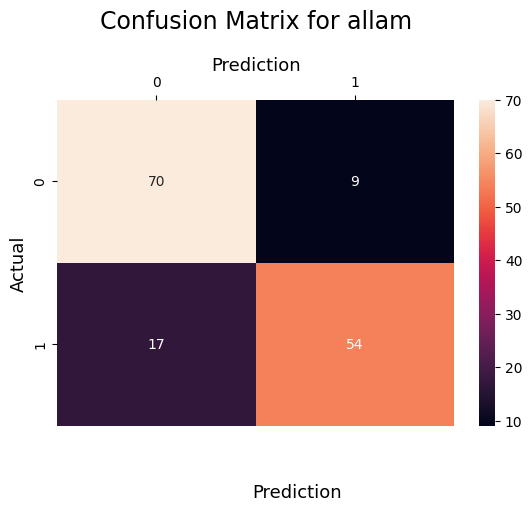

In [ ]:

allamacc = accuracy_score(true_labels, predicted_labels)
allamprecision = precision_score(true_labels, predicted_labels)
allamrecall = recall_score(true_labels, predicted_labels)
allamf1 = f1_score(true_labels, predicted_labels)

print("ALLAM Evaluation Metrics:")
print("Accuracy :", round(allamacc, 4))
print("Precision:", round(allamprecision, 4))
print("Recall   :", round(allamrecall, 4))
print("F1-Score :", round(allamf1, 4))
labels1 = np.unique(true_labels)
labels2 = np.unique(predicted_labels)
cm = confusion_matrix(true_labels,predicted_labels)
sns.heatmap(cm,  annot=True, fmt='g',  xticklabels=labels1,yticklabels= labels2)

plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix for allam', fontsize=17, pad=20)
plt.gca().xaxis.set_label_position('top')
plt.xlabel('Prediction', fontsize=13)
plt.gca().xaxis.tick_top()

plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)
plt.show()

In [ ]:

comparison = pd.DataFrame({
     "Model": ["Logistic Regression", "SVM", "Naive Bayes", "ALLAM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_nb), allamacc],
  "Precision": [precision_score(y_test, y_pred_lr, average='weighted'),precision_score(y_test, y_pred_svm, average='weighted'),
       precision_score(y_test, y_pred_nb, average='weighted'),allamprecision ],
    "Recall": [recall_score(y_test, y_pred_lr, average='weighted'),
      recall_score(y_test, y_pred_svm, average='weighted'),
        recall_score(y_test, y_pred_nb, average='weighted'),allamrecall ],
    "F1-Score": [
     f1_score(y_test, y_pred_lr, average='weighted'),
     f1_score(y_test, y_pred_svm, average='weighted'),
     f1_score(y_test, y_pred_nb, average='weighted'),allamf1  ]})

comparison = comparison.round(4)

print(comparison)

                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression    0.8540     0.8542  0.8540    0.8540
1                  SVM    0.8400     0.8400  0.8400    0.8400
2          Naive Bayes    0.8280     0.8290  0.8280    0.8277
3                ALLAM    0.8267     0.8571  0.7606    0.8060


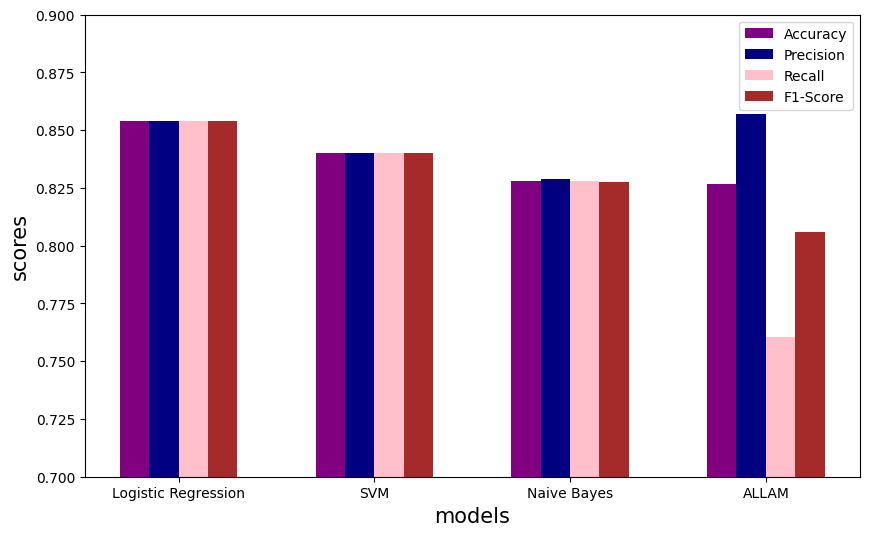

In [ ]:
width = 0.15
fig = plt.subplots(figsize =(10, 6))
x = np.arange(len(comparison["Model"]))

br1 = x - 1.5*width
br2 = x - 0.5*width
br3 = x + 0.5*width
br4 = x + 1.5*width

plt.bar(br1,comparison["Accuracy"], width, label='Accuracy',color='purple')
plt.bar(br2,comparison["Precision"],width, label='Precision',color='navy')
plt.bar(br3,comparison["Recall"],width, label='Recall',color='pink')
plt.bar(br4, comparison["F1-Score"], width, label='F1-Score',color='brown')

plt.xlabel('models', fontsize = 15)
plt.ylabel('scores',  fontsize = 15)
plt.xticks(x, comparison["Model"])
plt.ylim(0.7, 0.9)
plt.legend()
plt.show()